# Crater Detection — Binary Segmentation (U-Net)

This notebook trains a semantic segmentation model on the
[`gremlin97/crater_binary_segmentation`](https://huggingface.co/datasets/gremlin97/crater_binary_segmentation)
dataset and uses it to **mark every detected crater in red** on the original image.

**Dataset summary** (from the HF dataset card):
- 5.4k images total → `train` (3,600), `val` (900), `test` (900)
- Each row has an `image`, a binary `mask` (`Background` / `Crater`), plus `width`/`height`
- Images are 512×512 RGB

**Pipeline**
1. Load the dataset directly from the Hugging Face Hub (no manual download needed)
2. Train a U-Net (ResNet-34 encoder, ImageNet-pretrained) for binary crater segmentation
3. Evaluate with IoU / Dice on the held-out test split
4. Run inference and **overlay predicted craters in red** on the original images
5. Export the trained model as: a full checkpoint, raw weights, a config file, and ONNX — all downloadable

> **Kaggle setup (do this before running):** in the notebook side panel, turn **Internet ON**
> (needed for `pip install` and to stream the dataset from Hugging Face) and set
> **Accelerator → GPU T4 x2** (or P100). Training ~25 epochs at 256px takes roughly 20-40 minutes on a T4.


In [47]:
!nvidia-smi

Sun Aug 30 05:21:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             28W /   70W |    2801MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Install & import dependencies

In [48]:
%%capture
!pip install -q -U segmentation-models-pytorch albumentations datasets onnx onnxruntime

In [49]:
import os
import json
import random
import shutil

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from IPython.display import FileLink, display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss
from segmentation_models_pytorch import metrics as smp_metrics

from datasets import load_dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [50]:
# --- Paths ---
WORKING_DIR = "/kaggle/working"
CKPT_DIR = os.path.join(WORKING_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

# --- Model / training config ---
ENCODER_NAME = "resnet34"   # any encoder supported by segmentation_models_pytorch
IMG_SIZE = 256               # source images are 512x512; downscaled for faster training
BATCH_SIZE = 16
EPOCHS = 25
LR = 1e-4
NUM_WORKERS = 2

print("Checkpoints will be saved to:", CKPT_DIR)

Checkpoints will be saved to: /kaggle/working/checkpoints


## 2. Load the dataset from Hugging Face

In [51]:
dataset = load_dataset("gremlin97/crater_binary_segmentation")
print(dataset)

for split in dataset:
    print(f"{split}: {len(dataset[split])} samples")

sample = dataset["train"][0]
print("\nImage size:", sample["image"].size)
print("Mask size:", sample["mask"].size)
print("Class labels:", sample["class_labels"])

DatasetDict({
    train: Dataset({
        features: ['image', 'mask', 'width', 'height', 'class_labels'],
        num_rows: 3600
    })
    test: Dataset({
        features: ['image', 'mask', 'width', 'height', 'class_labels'],
        num_rows: 900
    })
    val: Dataset({
        features: ['image', 'mask', 'width', 'height', 'class_labels'],
        num_rows: 900
    })
})
train: 3600 samples
test: 900 samples
val: 900 samples

Image size: (512, 512)
Mask size: (512, 512)
Class labels: ['Background', 'Crater']


### A note on the mask encoding

This dataset's masks are single-channel images where the **pixel value is the class index**
(`0` = Background, `1` = Crater) — matching `class_labels: ["Background", "Crater"]`. That's a
common convention for HF segmentation datasets, but it means a naive `mask > 127` threshold
(which assumes 0/255-style masks) zeroes out *every* mask, since a pixel value of `1` never
clears 127. On top of that, the masks are stored as **JPEG**, which is lossy — so even the exact
0/1 values aren't guaranteed to survive compression perfectly.

The cell below prints the actual decoded pixel values so you can see this directly, and the
`binarize_mask()` helper that follows uses **Otsu thresholding** instead of a fixed cutoff — it
finds the right split point per-image automatically, so it works whether a mask decodes as
0/1, 0/255, or something JPEG-shifted in between.

In [52]:
# Inspect the raw, undecoded mask values for a few samples
for i in range(5):
    raw_mask = np.array(dataset["train"][i]["mask"].convert("L"))
    print(f"sample {i}: min={raw_mask.min()}, max={raw_mask.max()}, "
          f"unique={np.unique(raw_mask)[:10]}")

sample 0: min=0, max=1, unique=[0 1]
sample 1: min=0, max=1, unique=[0 1]
sample 2: min=0, max=1, unique=[0 1]
sample 3: min=0, max=1, unique=[0 1]
sample 4: min=0, max=1, unique=[0 1]


In [53]:
def binarize_mask(mask_arr):
    """Robustly binarize a mask that may use either the 0/255 convention or the
    0/1 class-index convention (this dataset's masks decode as the latter, and
    are JPEG-compressed on top of that). Uses Otsu thresholding so it adapts to
    whatever value range the mask actually decodes to, instead of assuming one."""
    mask_arr = mask_arr.astype(np.uint8)
    if mask_arr.max() == mask_arr.min():
        # Perfectly flat -> no crater signal in this tile, nothing to threshold
        return np.zeros_like(mask_arr, dtype=np.uint8)
    _, binarized = cv2.threshold(mask_arr, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binarized

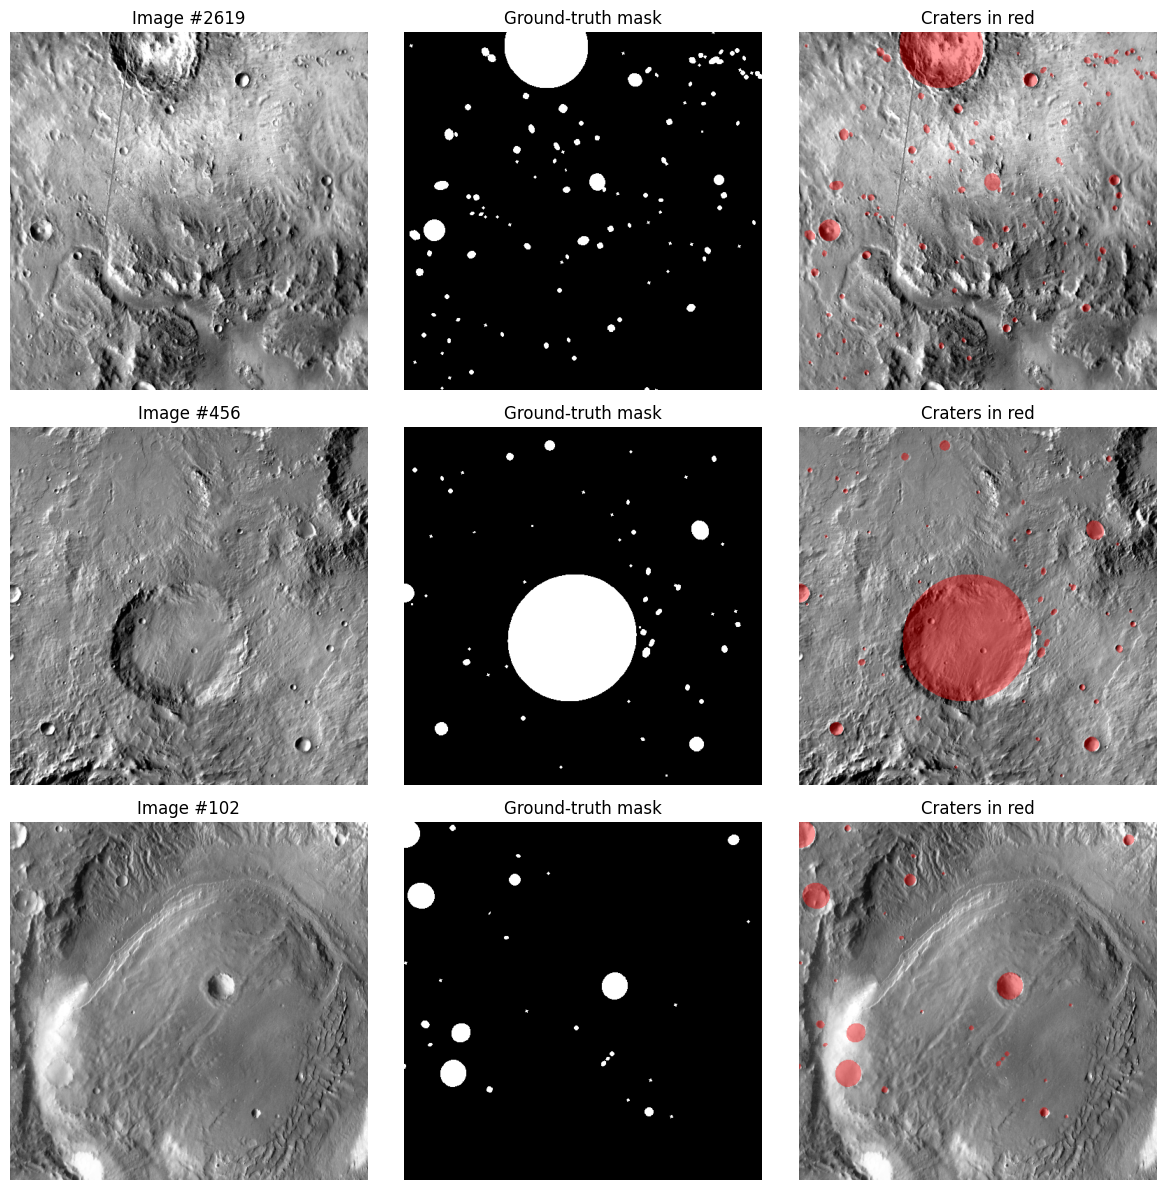

In [54]:
# Quick visual sanity check: original image | ground-truth mask | craters in red
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
demo_idx = random.sample(range(len(dataset["train"])), 3)

for row, idx in enumerate(demo_idx):
    item = dataset["train"][idx]
    image = np.array(item["image"].convert("RGB"))
    mask = np.array(item["mask"].convert("L"))
    mask_bin = binarize_mask(mask)

    red_overlay = image.copy()
    red_overlay[mask_bin.astype(bool)] = [255, 0, 0]
    blended = (0.6 * image + 0.4 * red_overlay).astype(np.uint8)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Image #{idx}")
    axes[row, 1].imshow(mask_bin, cmap="gray")
    axes[row, 1].set_title("Ground-truth mask")
    axes[row, 2].imshow(blended)
    axes[row, 2].set_title("Craters in red")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

## 3. PyTorch `Dataset` + augmentations

In [55]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


class CraterDataset(Dataset):
    """Wraps a split of the HF crater_binary_segmentation dataset as a PyTorch Dataset."""

    def __init__(self, hf_split, transform=None):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        image = np.array(item["image"].convert("RGB"))
        mask = np.array(item["mask"].convert("L"))
        mask = binarize_mask(mask).astype(np.float32)  # see binarize_mask() above

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.unsqueeze(0).float()  # -> (1, H, W)
        return image, mask

In [56]:
train_ds = CraterDataset(dataset["train"], transform=train_transform)
val_ds = CraterDataset(dataset["val"], transform=eval_transform)
test_ds = CraterDataset(dataset["test"], transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 225 | Val batches: 57 | Test batches: 57


## 4. Model — U-Net with a pretrained encoder

In [57]:
model = smp.Unet(
    encoder_name=ENCODER_NAME,
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: U-Net ({ENCODER_NAME} encoder) | {n_params:,} parameters")

Model: U-Net (resnet34 encoder) | 24,436,369 parameters


## 5. Loss & metrics

In [58]:
bce_loss_fn = nn.BCEWithLogitsLoss()
dice_loss_fn = DiceLoss(mode="binary", from_logits=True)


def criterion(logits, targets):
    return 0.5 * bce_loss_fn(logits, targets) + 0.5 * dice_loss_fn(logits, targets)


@torch.no_grad()
def compute_iou_dice(logits, targets, threshold=0.5):
    preds = (torch.sigmoid(logits) > threshold).long()
    tp, fp, fn, tn = smp_metrics.get_stats(preds, targets.long(), mode="binary")
    iou = smp_metrics.iou_score(tp, fp, fn, tn, reduction="micro").item()
    dice = smp_metrics.f1_score(tp, fp, fn, tn, reduction="micro").item()
    return iou, dice

## 6. Training loop

In [59]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for images, masks in tqdm(loader, desc="train", leave=False):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, running_iou, running_dice = 0.0, 0.0, 0.0
    for images, masks in tqdm(loader, desc="val", leave=False):
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        loss = criterion(logits, masks)
        iou, dice = compute_iou_dice(logits, masks)
        running_loss += loss.item() * images.size(0)
        running_iou += iou * images.size(0)
        running_dice += dice * images.size(0)
    n = len(loader.dataset)
    return running_loss / n, running_iou / n, running_dice / n

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

best_ckpt = os.path.join(CKPT_DIR, "crater_unet_best.pth")
best_val_iou = 0.0
history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_dice": []}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_iou, val_dice = validate(model, val_loader, criterion, device)
    scheduler.step(val_iou)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)
    history["val_dice"].append(val_dice)

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss {train_loss:.4f} | "
          f"val_loss {val_loss:.4f} | val_IoU {val_iou:.4f} | val_Dice {val_dice:.4f}")

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_iou": val_iou,
            "val_dice": val_dice,
            "encoder_name": ENCODER_NAME,
            "img_size": IMG_SIZE,
        }, best_ckpt)
        print(f"  -> saved new best checkpoint (val_IoU={val_iou:.4f})")

print(f"\nBest val IoU: {best_val_iou:.4f} | checkpoint: {best_ckpt}")

train:   0%|          | 0/225 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d285ad8f560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d285ad8f560>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d285ad8f560>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in 

val:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 01/25 | train_loss 0.1714 | val_loss 0.2083 | val_IoU 0.6201 | val_Dice 0.7623
  -> saved new best checkpoint (val_IoU=0.6201)


train:   0%|          | 0/225 [00:00<?, ?it/s]

...

Epoch 10/25 | train_loss 0.1546 | val_loss 0.2056 | val_IoU 0.6212 | val_Dice 0.7632


train:   0%|          | 0/225 [00:00<?, ?it/s]

val:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 11/25 | train_loss 0.1513 | val_loss 0.1942 | val_IoU 0.6425 | val_Dice 0.7787
  -> saved new best checkpoint (val_IoU=0.6425)


train:   0%|          | 0/225 [00:00<?, ?it/s]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["val_iou"], label="val IoU")
axes[1].plot(history["val_dice"], label="val Dice")
axes[1].set_title("Validation metrics")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Load the best checkpoint & evaluate on the test set

In [ ]:
checkpoint = torch.load(best_ckpt, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} (val_IoU={checkpoint['val_iou']:.4f})")

In [ ]:
test_loss, test_iou, test_dice = validate(model, test_loader, criterion, device)
print(f"Test | loss {test_loss:.4f} | IoU {test_iou:.4f} | Dice {test_dice:.4f}")

## 8. Mark every crater in red

This is the core deliverable: given any image, the model predicts a crater mask and every
crater pixel is tinted red on top of the original photo.

In [ ]:
def predict_mask(model, pil_image, img_size, device, threshold=0.5):
    """Run the model on a PIL image, return a binary mask at the ORIGINAL image resolution."""
    orig_w, orig_h = pil_image.size
    image_rgb = np.array(pil_image.convert("RGB"))

    transformed = eval_transform(image=image_rgb, mask=np.zeros((orig_h, orig_w), dtype=np.float32))
    input_tensor = transformed["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()

    mask_small = (prob > threshold).astype(np.uint8)
    mask_full = cv2.resize(mask_small, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    return mask_full


def mark_craters_red(pil_image, mask, alpha=0.55):
    """Return an RGB uint8 array with every predicted crater pixel tinted red."""
    image_rgb = np.array(pil_image.convert("RGB")).astype(np.float32)
    red_layer = np.zeros_like(image_rgb)
    red_layer[..., 0] = 255

    mask_bool = mask.astype(bool)
    blended = image_rgb.copy()
    blended[mask_bool] = alpha * red_layer[mask_bool] + (1 - alpha) * image_rgb[mask_bool]
    return blended.astype(np.uint8)

In [ ]:
# Demo on a handful of held-out test images
n_demo = 4
demo_indices = random.sample(range(len(dataset["test"])), n_demo)

fig, axes = plt.subplots(n_demo, 3, figsize=(12, 4 * n_demo))
for row, idx in enumerate(demo_indices):
    pil_image = dataset["test"][idx]["image"]
    gt_mask = binarize_mask(np.array(dataset["test"][idx]["mask"].convert("L")))

    pred_mask = predict_mask(model, pil_image, IMG_SIZE, device)
    red_overlay = mark_craters_red(pil_image, pred_mask)

    axes[row, 0].imshow(pil_image)
    axes[row, 0].set_title("Original")
    axes[row, 1].imshow(gt_mask, cmap="gray")
    axes[row, 1].set_title("Ground truth")
    axes[row, 2].imshow(red_overlay)
    axes[row, 2].set_title("Predicted craters (red)")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# --- Try it on your own image ---
# custom_image = Image.open("/kaggle/input/datasets/quasarxy/lunarim/Screenshot 2026-08-27 000453.png")
# custom_mask = predict_mask(model, custom_image, IMG_SIZE, device)
# custom_overlay = mark_craters_red(custom_image, custom_mask)
# plt.figure(figsize=(6, 6))
# plt.imshow(custom_overlay)
# plt.axis("off")
# plt.show()

## 9. Export the trained model in multiple portable formats

In [ ]:
!pip install onnxscript
# --- Export the trained model in multiple portable formats ---
model.eval()
# 1) Plain state_dict -- smallest, most portable file for reuse in plain PyTorch
weights_path = os.path.join(CKPT_DIR, "crater_unet_weights.pth")
torch.save(model.state_dict(), weights_path)
# 2) Config needed to rebuild the exact architecture elsewhere (state_dict alone
#    isn't enough -- whoever loads it needs to know the encoder/input/output shape)
config_path = os.path.join(CKPT_DIR, "model_config.json")
with open(config_path, "w") as f:
    json.dump({
        "encoder_name": ENCODER_NAME,
        "encoder_weights": None,
        "in_channels": 3,
        "classes": 1,
        "img_size": IMG_SIZE,
        "input_format": "RGB, HWC->CHW, float32 divided by 255.0",
        "output_format": "single-channel logits; apply sigmoid for probability",
    }, f, indent=2)
# 3) ONNX -- runs via ONNX Runtime in Python, C++, C#, Java, JS, mobile, etc.,
#    with no PyTorch dependency at inference time
onnx_path = os.path.join(CKPT_DIR, "crater_unet.onnx")
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={"input": {0: "batch_size", 2: "height", 3: "width"},
                  "logits": {0: "batch_size", 2: "height", 3: "width"}},
)
print(f"Exported ONNX model to: {onnx_path}")
# Verify the ONNX model numerically matches PyTorch before trusting it anywhere else
try:
    import onnx
    import onnxruntime as ort
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    ort_session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
    with torch.no_grad():
        torch_out = model(dummy_input).cpu().numpy()
    ort_out = ort_session.run(None, {"input": dummy_input.cpu().numpy()})[0]
    max_diff = float(np.abs(torch_out - ort_out).max())
    print(f"Max abs difference between PyTorch and ONNX Runtime outputs: {max_diff:.2e}")
    assert max_diff < 1e-3, "ONNX export does not numerically match PyTorch output!"
    print("\u2705 ONNX export verified -- outputs match PyTorch within tolerance.")
except ImportError:
    print("Install 'onnx' and 'onnxruntime' to verify the export.")
print("\nSaved portable artifacts:")
print(f" - {best_ckpt}   (full training checkpoint -- resume training from here)")
print(f" - {weights_path}   (raw model weights only -- for inference elsewhere)")
print(f" - {config_path}   (architecture config needed to rebuild the model)")
print(f" - {onnx_path}   (ONNX -- runs anywhere via onnxruntime)")
display(FileLink(os.path.relpath(weights_path, WORKING_DIR)))
display(FileLink(os.path.relpath(config_path, WORKING_DIR)))
display(FileLink(os.path.relpath(onnx_path, WORKING_DIR)))

## 10. One-click download: zip every artifact

In [ ]:
zip_base = os.path.join(WORKING_DIR, "crater_model_export")
shutil.make_archive(zip_base, "zip", CKPT_DIR)
print(f"All artifacts zipped to: {zip_base}.zip")
display(FileLink(os.path.relpath(zip_base + ".zip", WORKING_DIR)))

## Summary

- **Model**: U-Net (`segmentation_models_pytorch`) with a ResNet-34 ImageNet-pretrained encoder, trained for binary crater segmentation.
- **Result**: craters are marked in red directly on the input image via `mark_craters_red()`.
- **Downloadable artifacts** (in `/kaggle/working/checkpoints`, zipped as `crater_model_export.zip`):
  - `crater_unet_best.pth` — full training checkpoint (resume training)
  - `crater_unet_weights.pth` — plain `state_dict` for inference in PyTorch
  - `model_config.json` — architecture config needed to rebuild the model elsewhere
  - `crater_unet.onnx` — framework-independent export, runs via ONNX Runtime anywhere

**To download from Kaggle:** while the notebook is running interactively, click any of the `FileLink`
links above. After a "Save & Run All (Commit)", all files under `/kaggle/working` are also listed in
the notebook's **Output** tab, ready to download from there.

**To improve results further:** try a larger `IMG_SIZE` (e.g. 384/512), a bigger encoder
(`resnet50`, `efficientnet-b3`), more epochs, or `smp.UnetPlusPlus` / `smp.DeepLabV3Plus` as
drop-in alternatives to `smp.Unet`.
